In [3]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next(
    p for p in (cwd, *cwd.parents)
    if (p / "rebound").is_dir() and (p / "src").is_dir()
)
sys.path.insert(0, str(repo_root))

import rebound
import ctypes
import numpy as np
import matplotlib.pyplot as plt

def getSim(m=1.0, encounter=True):
    sim = rebound.Simulation()
    sim.add(m=1)
    sim.add(m=1e-6*m, a=1)
    if encounter: 
        planet = sim.particles[-1]
        asteroid = planet.copy()
        asteroid.x += 0.001
        o = asteroid.orbit(primary=planet)
        vesc = np.sqrt(2*(planet.m+asteroid.m)/o.d)
        asteroid.vy += 1.2*vesc
        sim.add(asteroid)
    else:
        sim.add(m=1e-6*m, a=1.5)
    sim.integrate(-np.pi)
    sim.t = 0
    sim.dt = 0.2
    return sim

_hj_tree_to_string = rebound.clibrebound.reb_integrator_whfast_hj_tree_to_string
_hj_tree_to_string.argtypes = [ctypes.c_void_p, ctypes.c_char_p, ctypes.c_size_t]
_hj_tree_to_string.restype = ctypes.c_int

def hj_tree_string(sim):
    size = 1024

    while True:
        buf = ctypes.create_string_buffer(size)
        n = _hj_tree_to_string(ctypes.byref(sim), buf, size)

        if n < 0:
            raise RuntimeError("Cannot determine HJ tree.")

        if n < size:
            return buf.value.decode()

        size = n + 1


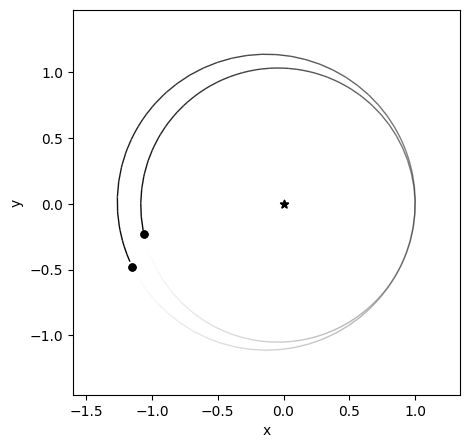

In [4]:
sim = getSim()
rebound.OrbitPlot(sim)

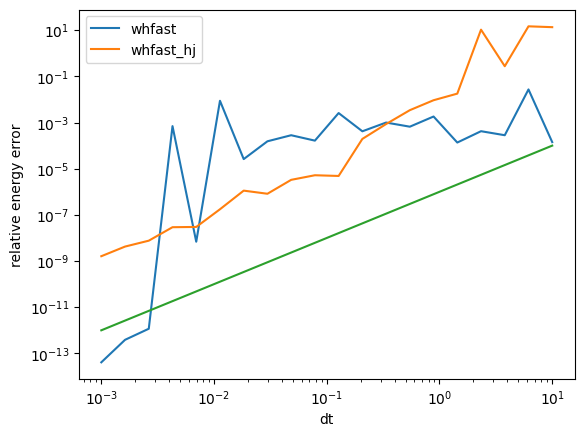

In [ ]:
dts = np.logspace(-3,1,20)
Es = np.zeros(len(dts))
Es_hj = np.zeros(len(dts))
for i, dt in enumerate(dts):
    sim = getSim()
    sim.integrator = "whfast"
    sim.dt = dt
    E0 = sim.energy()
    sim.integrate(500)
    E1 = sim.energy()
    Es[i] = np.abs((E0-E1)/E0)

    sim = getSim()
    sim.integrator = "whfast_hj"
    sim.dt = dt
    E0 = sim.energy()
    sim.integrate(500)
    E1 = sim.energy()
    Es_hj[i] = np.abs((E0-E1)/E0)
    
fig,ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
ax.plot(dts, Es, label="whfast")
ax.plot(dts, Es_hj, label="whfast_hj")
ax.set_xlabel("dt")
ax.set_ylabel("relative energy error")
ax.legend()
ax.plot(dts, 1e-6*dts**2)


# loglog plot, dt vs energy error, with a line showing dt^2 scaling.


m=  0.01
t = 0.200, tree = [1,[3,2]]
t = 0.400, tree = [1,[3,2]]
t = 0.600, tree = [1,[3,2]]
t = 0.800, tree = [1,[3,2]]
t = 1.000, tree = [1,[3,2]]
t = 1.200, tree = [1,[3,2]]
t = 1.400, tree = [1,[3,2]]
t = 1.600, tree = [1,[3,2]]
t = 1.800, tree = [1,[3,2]]
t = 2.000, tree = [1,[3,2]]
t = 2.200, tree = [1,[3,2]]
t = 2.400, tree = [1,[3,2]]
t = 2.600, tree = [1,[3,2]]
t = 2.800, tree = [1,[3,2]]
t = 3.000, tree = [1,[3,2]]
t = 3.200, tree = [1,[3,2]]
t = 3.400, tree = [1,[3,2]]
t = 3.600, tree = [1,[3,2]]
t = 3.800, tree = [1,[3,2]]
t = 4.000, tree = [1,[3,2]]
t = 4.200, tree = [1,[3,2]]
t = 4.400, tree = [1,[3,2]]
t = 4.600, tree = [1,[3,2]]
t = 4.800, tree = [1,[3,2]]
t = 5.000, tree = [1,[3,2]]
t = 5.200, tree = [1,[3,2]]
t = 5.400, tree = [1,[3,2]]
t = 5.600, tree = [1,[3,2]]
t = 5.800, tree = [1,[3,2]]
t = 6.000, tree = [1,[3,2]]
t = 6.200, tree = [1,[3,2]]
t = 6.400, tree = [1,[3,2]]
t = 6.600, tree = [1,[3,2]]
t = 6.800, tree = [1,[3,2]]
t = 7.000, tree = [1,[3,2]]
t = 7.200, 

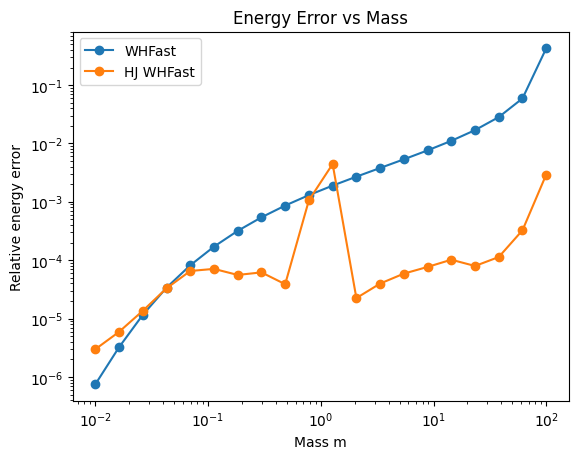

In [ ]:
ms = np.logspace(-2,2,20)
Es = np.zeros(len(ms))
Es_HJ = np.zeros(len(ms))
for i, m in enumerate(ms):
    print("m= ", m)
    
    # regular Jacobin run
    sim = getSim(m=m)
    sim.integrator = "whfast"
    sim.dt = 0.2
    E0 = sim.energy()
    # sim.integrate(np.pi*2) 
    tmax = 20
    while sim.t < tmax:
        sim.integrate(sim.t + sim.dt)
    E1 = sim.energy()
    Es[i] = np.abs((E0-E1)/E0)


    # HJ Jacobin run
    sim = getSim(m=m)
    sim.integrator = "whfast_hj"
    sim.dt = 0.2
    E0 = sim.energy()
    # sim.integrate(np.pi*2) 

    tmax = 20
    while sim.t < tmax:
        sim.integrate(sim.t + sim.dt)
        print(f"t = {sim.t:.3f}, tree = {hj_tree_string(sim)}")
    E1 = sim.energy()
    Es_HJ[i] = np.abs((E0-E1)/E0)


fig,ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
ax.plot(ms, Es, marker="o", label="WHFast")
ax.plot(ms, Es_HJ, marker="o", label="HJ WHFast")

ax.set_xlabel("Mass m")
ax.set_ylabel("Relative energy error")
ax.set_title("Energy Error vs Mass")

ax.legend()
plt.show()

# log log plot, mass vs energy error, here we see error whfast_hj is around 10^{-4} for reasonable mass ratios
#  but when m is near 1, we have a peakin error.
# we also see that when m < 2, start with [1,[3,2]], m >= 2, start with [1,[2,3]], which is consistent with the HJ tree structure.

In [ ]:
sim = getSim(m=100)
sim.integrator = "whfast_hj"
sim321 = rebound.Simulation()
sim321.G = sim.G
sim321.dt = sim.dt

sim321.add(sim.particles[2].copy())  # old particle 3
sim321.add(sim.particles[1].copy())  # old particle 2
sim321.add(sim.particles[0].copy())  # old particle 1

for i in range(20):
    sim321.integrate(sim321.t + sim321.dt)
    sim321.t += sim321.dt
    print(hj_tree_string(sim321))

# add in reverse order, we see the correct HJ tree structure.
# [[3,2],1] is original order [[1,2],3]
# In close encounter, we have [3,[2,1]](original order[1,[2,3]]), which is also consistent with the HJ tree structure.

[[3,2],1]
[[3,2],1]
[[3,2],1]
[[3,2],1]
[[3,2],1]
[[3,2],1]
[[3,2],1]
[[3,2],1]
[[3,2],1]
[[3,2],1]
[3,[2,1]]
[3,[2,1]]
[3,[2,1]]
[3,[2,1]]
[3,[2,1]]
[3,[2,1]]
[3,[2,1]]
[3,[2,1]]
[3,[2,1]]
[3,[2,1]]


In [ ]:
sim = rebound.Simulation()
sim.add("solar system")
E0 = sim.energy()

for i in range(300):
    sim.integrate(sim.t + sim.dt)
    print(hj_tree_string(sim))
E1 = sim.energy()
print("HJ WHFast:")
print(f"dE = {abs((E0 - E1) / E0):e}")

# regular whfast
print("Regular WHFast:")
sim = rebound.Simulation()
sim.dt = 0.1
sim.integrator = "whfast"
sim.add("solar system")
E0 = sim.energy()
sim.integrate(100 * np.pi * 2)
E1 = sim.energy()
print(f"dE = {abs((E0 - E1) / E0):e}")

# solar system, we see expected HJ tree structure.
# we also see that the energy error of HJ WHFast looks good

[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3],4],5],6],7],8],9]
[[[[[[[[1,2],3

In [ ]:
# here is simulation with 3 body, no close encounter.

def getSim_wrong_order(m=1.0):
    sim = rebound.Simulation()
    sim.add(m=1)
    sim.add(m=1e-3*m, a=1)
    sim.add(m=1e-3*m, a=2)
    sim.dt = 0.2
    sim321 = rebound.Simulation()
    sim321.G = sim.G
    sim321.dt = sim.dt

    sim321.add(sim.particles[0].copy())  # old particle 3
    sim321.add(sim.particles[2].copy())  # old particle 2
    sim321.add(sim.particles[1].copy())  # old particle 1
    return sim321

def getSim_correct_order(m=1.0):
    sim = rebound.Simulation()
    sim.add(m=1)
    sim.add(m=1e-3*m, a=1)
    sim.add(m=1e-3*m, a=2)
    sim.dt = 0.2
    sim.integrator = "whfast_hj"

    return sim

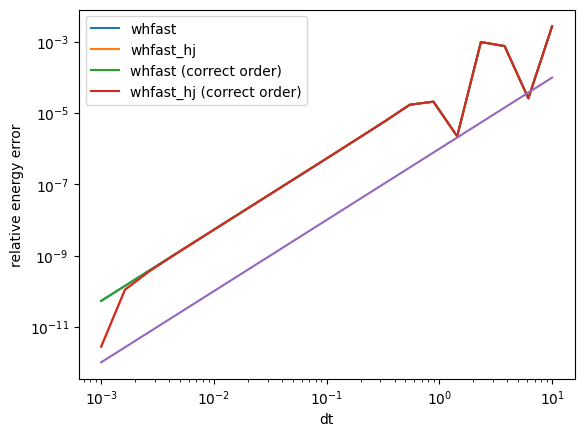

In [ ]:
dts = np.logspace(-3,1,20)
Es = np.zeros(len(dts))
Es_hj = np.zeros(len(dts))
Es_correct_order = np.zeros(len(dts))
Es_correct_order_hj = np.zeros(len(dts))


for i, dt in enumerate(dts):
    sim = getSim_wrong_order()
    sim.integrator = "whfast"
    sim.dt = dt
    E0 = sim.energy()
    sim.integrate(50)
    E1 = sim.energy()
    Es[i] = np.abs((E0-E1)/E0)

    sim = getSim_wrong_order()
    sim.integrator = "whfast_hj"
    sim.dt = dt
    E0 = sim.energy()
    sim.integrate(50)

    E1 = sim.energy()
    Es_hj[i] = np.abs((E0-E1)/E0)

    sim = getSim_correct_order()
    sim.integrator = "whfast"
    sim.dt = dt
    E0 = sim.energy()
    sim.integrate(50)

    E1 = sim.energy()
    Es_correct_order[i] = np.abs((E0-E1)/E0)
    E1 = sim.energy()
    Es[i] = np.abs((E0-E1)/E0)

    sim = getSim_correct_order()
    sim.integrator = "whfast_hj"
    sim.dt = dt
    E0 = sim.energy()
    sim.integrate(50)

    E1 = sim.energy()
    Es_correct_order_hj[i] = np.abs((E0-E1)/E0)
    
fig,ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
ax.plot(dts, Es, label="whfast")
ax.plot(dts, Es_hj, label="whfast_hj")
ax.plot(dts, Es_correct_order, label="whfast (correct order)")
ax.plot(dts, Es_correct_order_hj, label="whfast_hj (correct order)")
ax.set_xlabel("dt")
ax.set_ylabel("relative energy error")
ax.legend()
ax.plot(dts, 1e-6*dts**2)

# here we see that, hj is the same as regular whfast. 
# no matter the order, we have the same energy error.